In [1]:
import pathlib

import pandas as pd
import numpy as np
import torch

from sklearn.metrics import roc_auc_score, average_precision_score
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from torch_geometric.nn import MessagePassing
from captum.attr import IntegratedGradients, Saliency
from rdkit.Chem import rdMolAlign
from rdkit.Chem import AllChem

from mpnn import visualize_all_activations, AllNonZeroReadout
from highlight_smarts import highlight_atoms_in_mol, visualize_smarts_match
from krfp_models import krfp_models, name_to_post_smarts, name_to_pre_smarts
from mpnn import one_hot_encode, smiles_to_torch, mol_to_torch, MoleculeGDetector
from datavis import visualize_atom_importance, visualize_atom_importance_from_mol
from mpnn.mpnn_arch import AllNonZeroMaxReadout, AllNonZeroSumReadout

from xai_methods import IGAttributionMethod, SaliencyAttributionMethod
from xai_methods.captum_attributions import ShapleyValueSamplingAttributionMethod
from notebook_utils import get_ig_gradient_paths

/home/dominik/MyStuff/bxaic2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Question: Is there any case where IG fails but Saliency doesn't?

readout_1_directory = pathlib.Path("artifacts/explainability_method_tester/R1")
readout_2_directory = pathlib.Path("artifacts/explainability_method_tester/R2")

subfolders_readout_1 = [f.name for f in readout_1_directory.iterdir() if f.is_dir()]
subfolders_readout_2 = [f.name for f in readout_2_directory.iterdir() if f.is_dir()]

subfolders_readout_1 = sorted(subfolders_readout_1)
subfolders_readout_2 = sorted(subfolders_readout_2)

assert subfolders_readout_1 == subfolders_readout_2, "The subfolder names (which correspond to model names) should be the same in both directories."

for i, subdir_name in enumerate(subfolders_readout_1):
    print(f"For model {i} {subdir_name}:")

    readout_1_csv = readout_1_directory / subdir_name / "positive_explainability_results.csv"
    readout_2_csv = readout_2_directory / subdir_name / "positive_explainability_results.csv"

    df_readout_1 = pd.read_csv(readout_1_csv)
    df_readout_2 = pd.read_csv(readout_2_csv)

    df_readout_1 = df_readout_1.dropna(subset=["Saliency_auroc"])
    df_readout_2 = df_readout_2.dropna(subset=["Integrated Gradients_auroc"])

    df_readout_1 = df_readout_1[df_readout_1["Saliency_auroc"] != 1.0]
    df_readout_2 = df_readout_2[df_readout_2["Integrated Gradients_auroc"] != 1.0]

    saliency_failing_smiles = set(df_readout_1["SMILES"].dropna().tolist())
    ig_failing_smiles = set(df_readout_2["SMILES"].dropna().tolist())

    only_saliency_failing_smiles = saliency_failing_smiles - ig_failing_smiles
    only_ig_failing_smiles = ig_failing_smiles - saliency_failing_smiles

    print("Number of SMILES where only Saliency fails:", len(only_saliency_failing_smiles))
    print("Number of SMILES where only IG fails:", len(only_ig_failing_smiles))
    print("Number of SMILES where IG fails:", len(ig_failing_smiles))

    if len(only_ig_failing_smiles) > 0:
        print("SMILES where only IG fails:", only_ig_failing_smiles)

For model 0 MoleculeCDetector:
Number of SMILES where only Saliency fails: 168
Number of SMILES where only IG fails: 0
Number of SMILES where IG fails: 39
For model 1 MoleculeEDetector:
Number of SMILES where only Saliency fails: 3
Number of SMILES where only IG fails: 0
Number of SMILES where IG fails: 0
For model 2 MoleculeFDetector:
Number of SMILES where only Saliency fails: 0
Number of SMILES where only IG fails: 0
Number of SMILES where IG fails: 0
For model 3 MoleculeGDetector:
Number of SMILES where only Saliency fails: 52
Number of SMILES where only IG fails: 0
Number of SMILES where IG fails: 173
For model 4 MoleculeHDetector:
Number of SMILES where only Saliency fails: 3
Number of SMILES where only IG fails: 1
Number of SMILES where IG fails: 2
SMILES where only IG fails: {'NC(=O)NN=C1CCCC(C(=O)O)C1'}
For model 5 MoleculeIDetector:
Number of SMILES where only Saliency fails: 2516
Number of SMILES where only IG fails: 0
Number of SMILES where IG fails: 0
For model 6 MoleculeJ

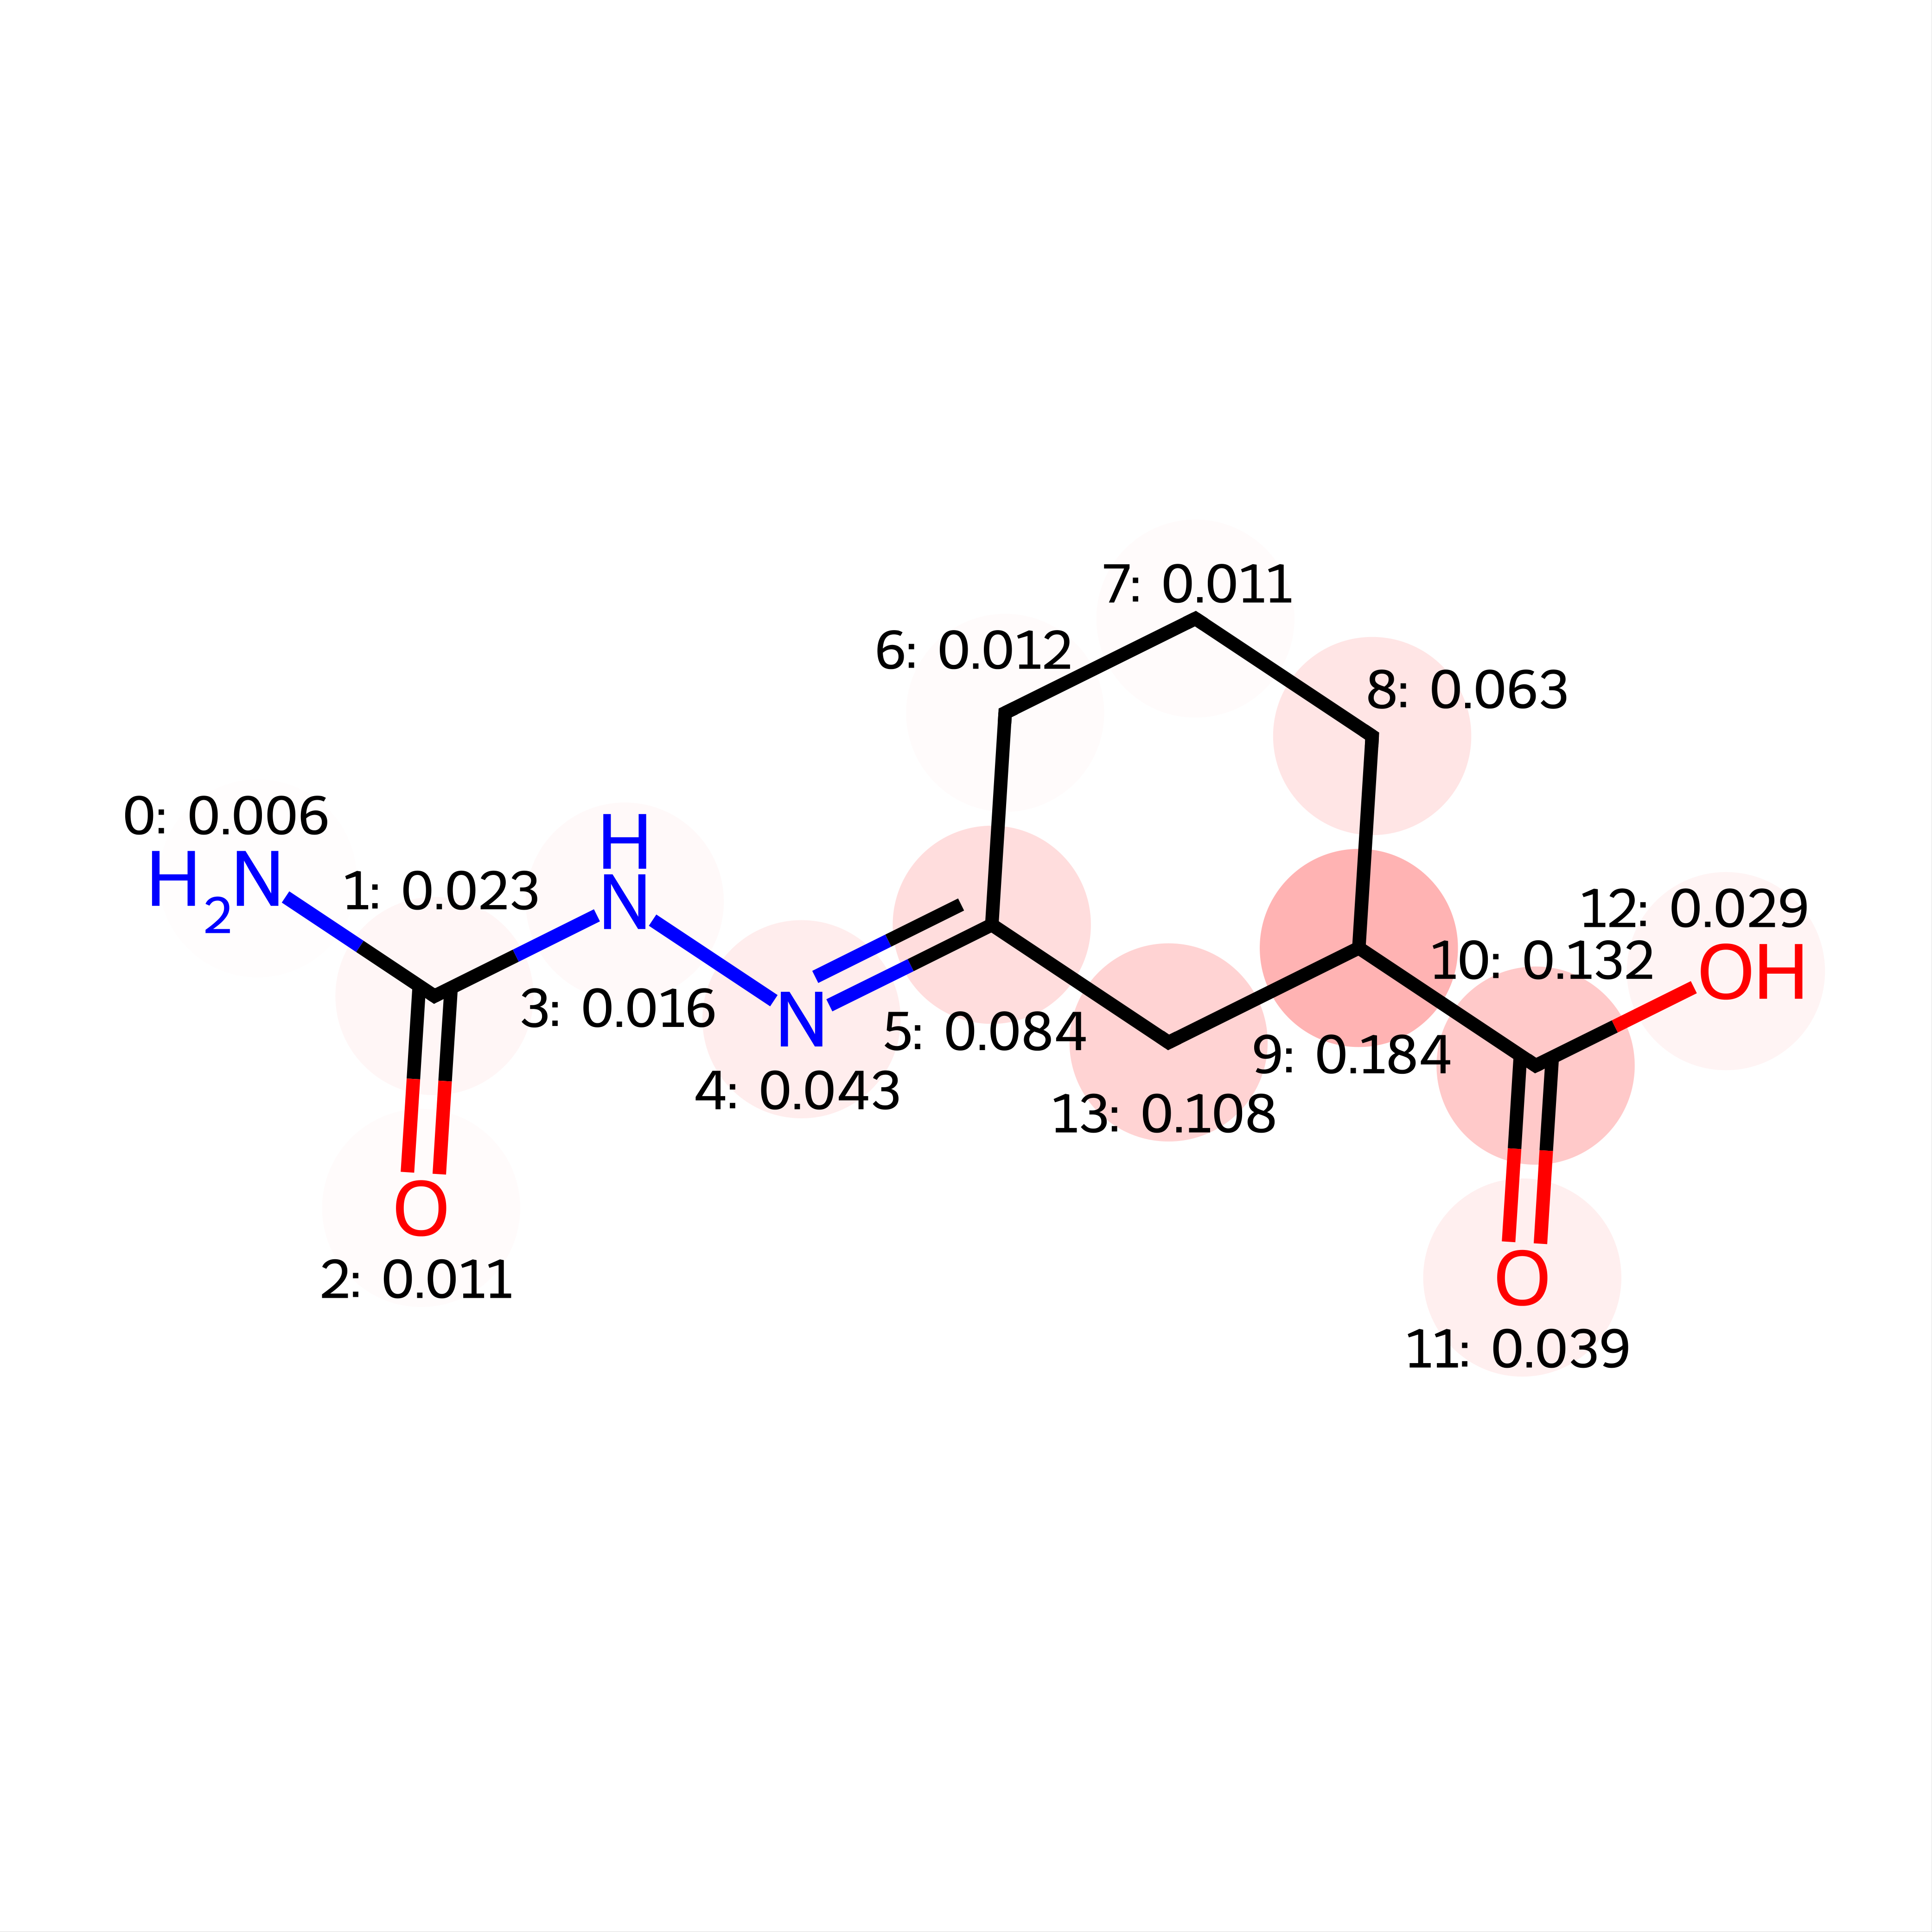

In [3]:
from mpnn import MoleculeHDetector

ultimately_suspicious_smiles = "NC(=O)NN=C1CCCC(C(=O)O)C1"

mol = Chem.MolFromSmiles(ultimately_suspicious_smiles)
mol = Chem.RemoveAllHs(mol)

x, edge_index, edge_features = mol_to_torch(mol)

smarts_post = name_to_post_smarts["MoleculeHDetector"]
model = MoleculeHDetector()
model.readout = AllNonZeroReadout()

ig_explainer = IGAttributionMethod(
    model=model,
    model_smarts=smarts_post,
    positive_smiles=[],  # Not used in this case, but required by the interface
    negative_smiles=[],
)

atom_importance, edge_importance = ig_explainer.explain(x, edge_features, edge_index)

atom_importance = torch.sum(torch.abs(atom_importance), dim=1).cpu().numpy().tolist()
img = visualize_atom_importance_from_mol(
    mol,
    atom_importance,
    length=1000,
    bond_line_width=7,
    annotation_font_scale=0.7,
    precision=3,
    show_atom_idx=True
)

img

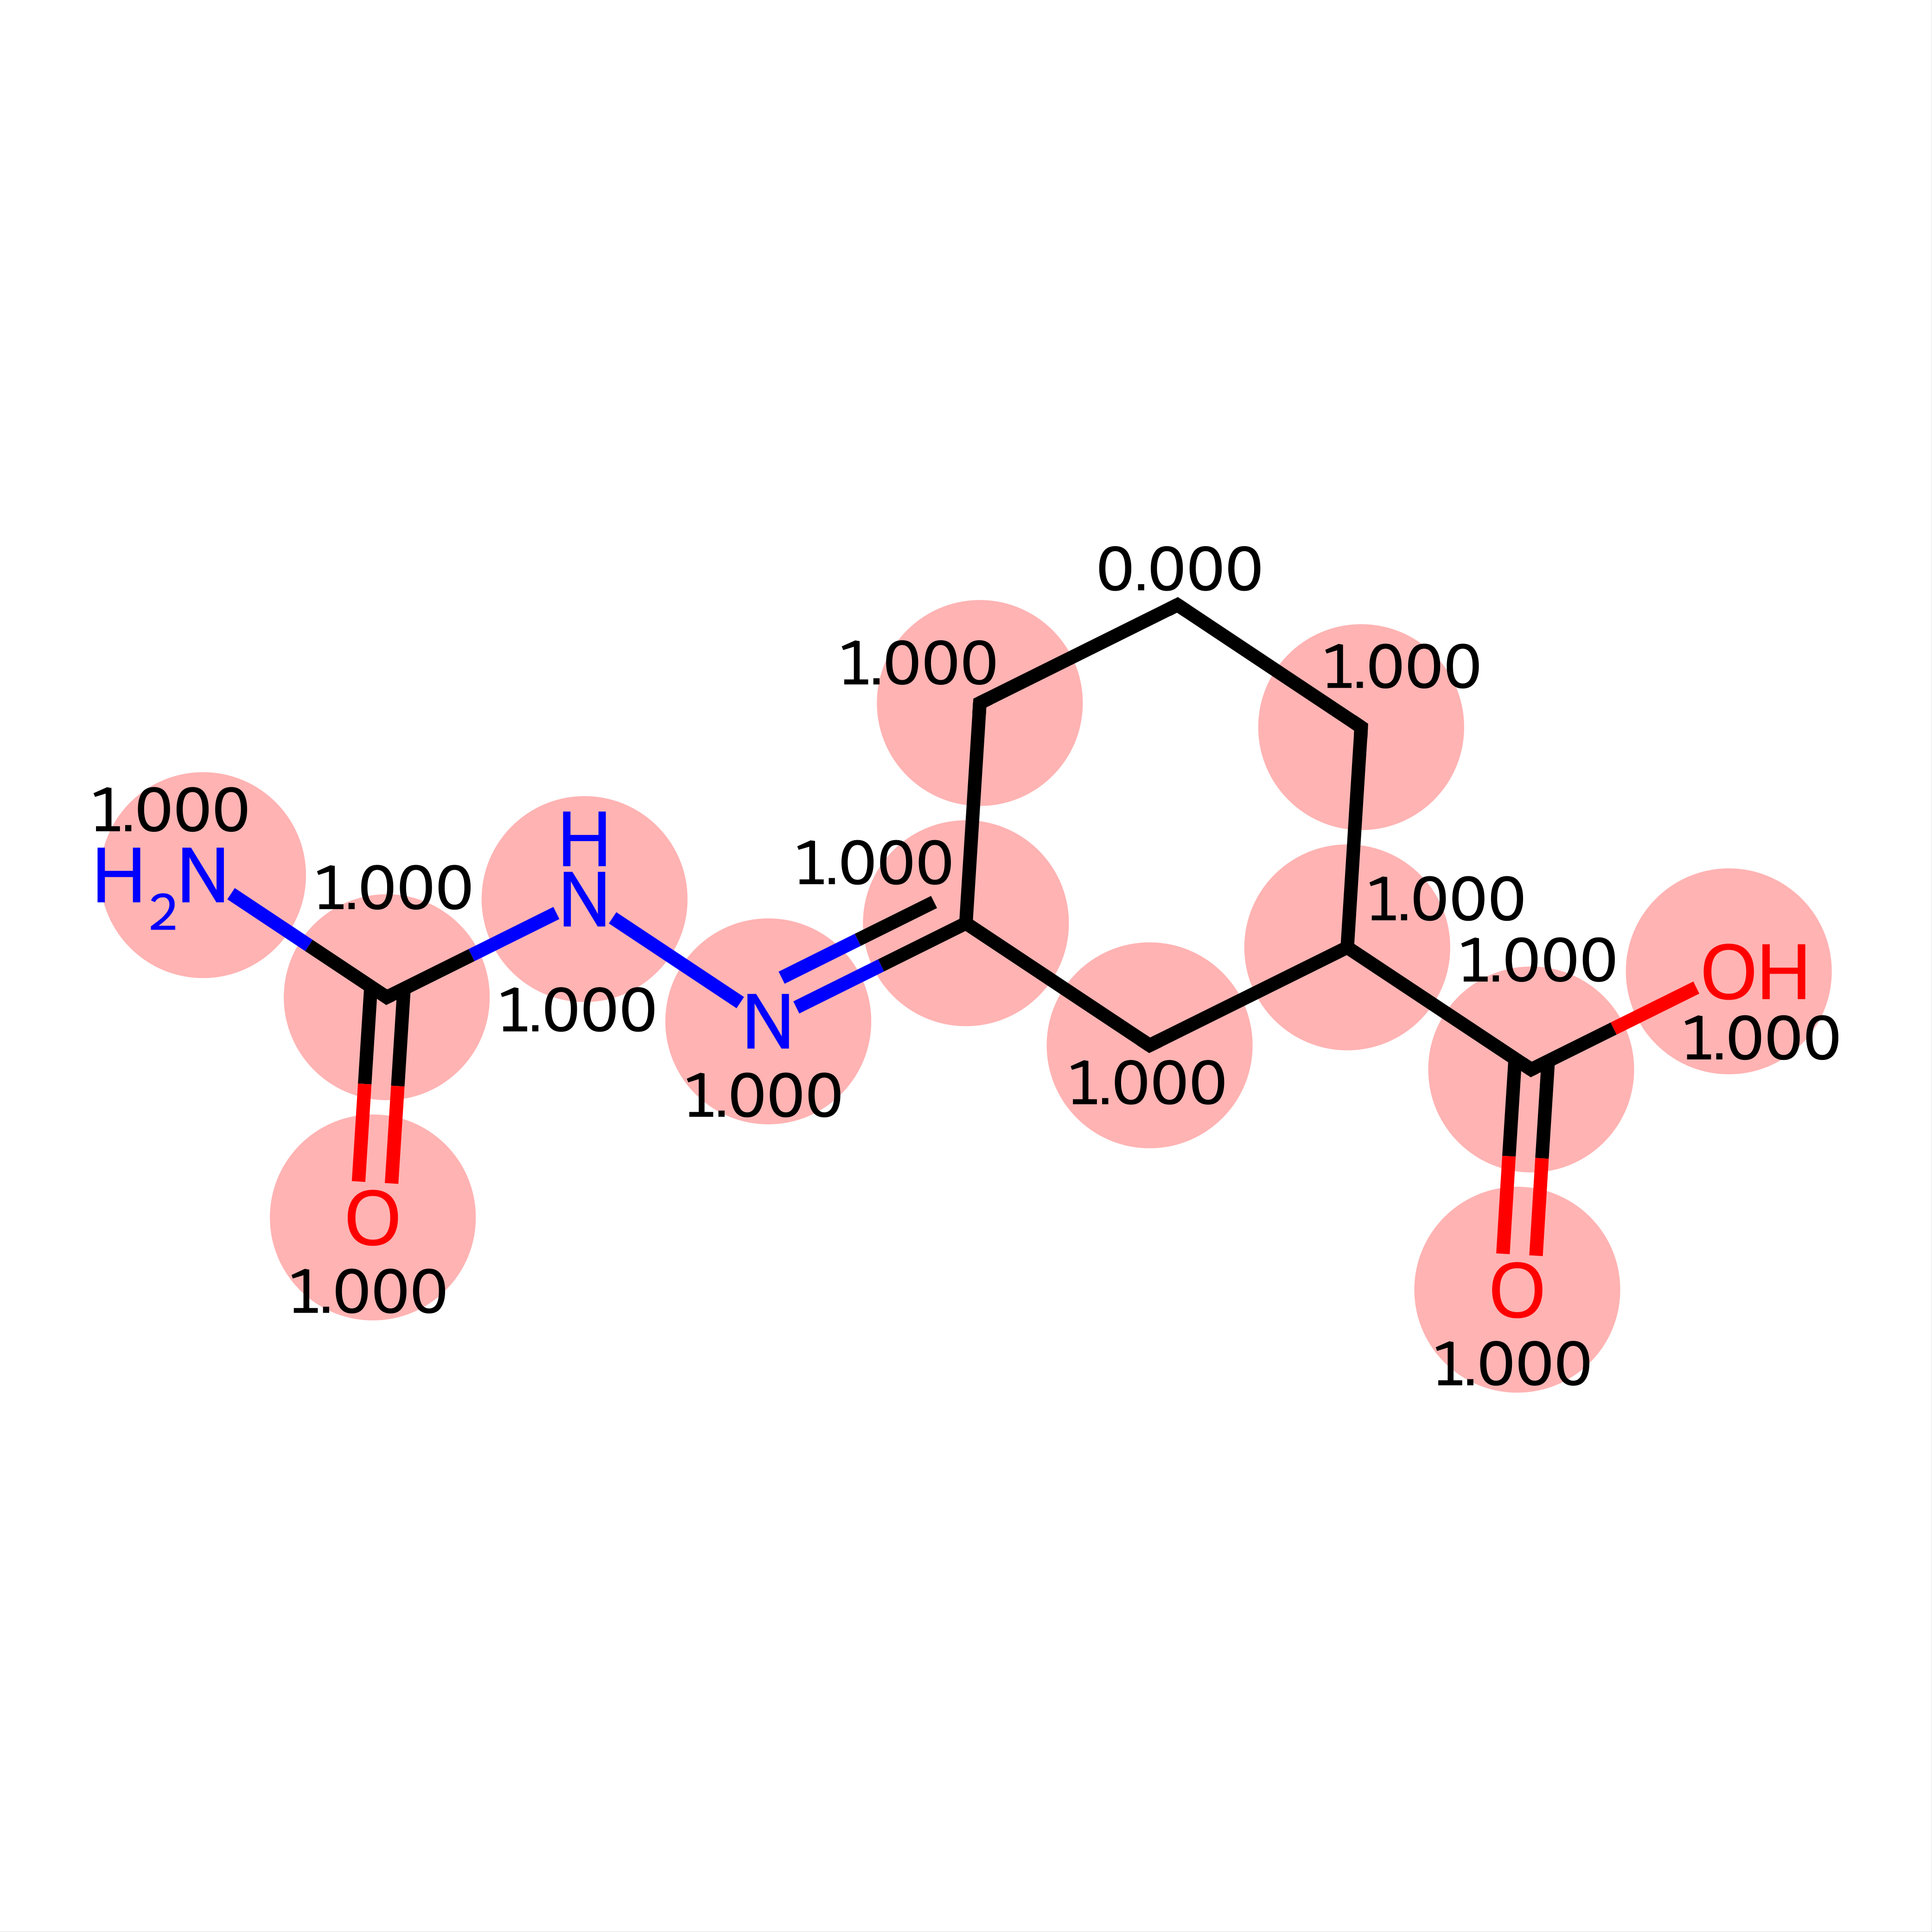

In [4]:
baseline_img = visualize_smarts_match(
    mol,
    smarts_post,
    bond_line_width=7,
    annotation_font_scale=0.8,
    precision=3,
    radius=0.7
)

baseline_img


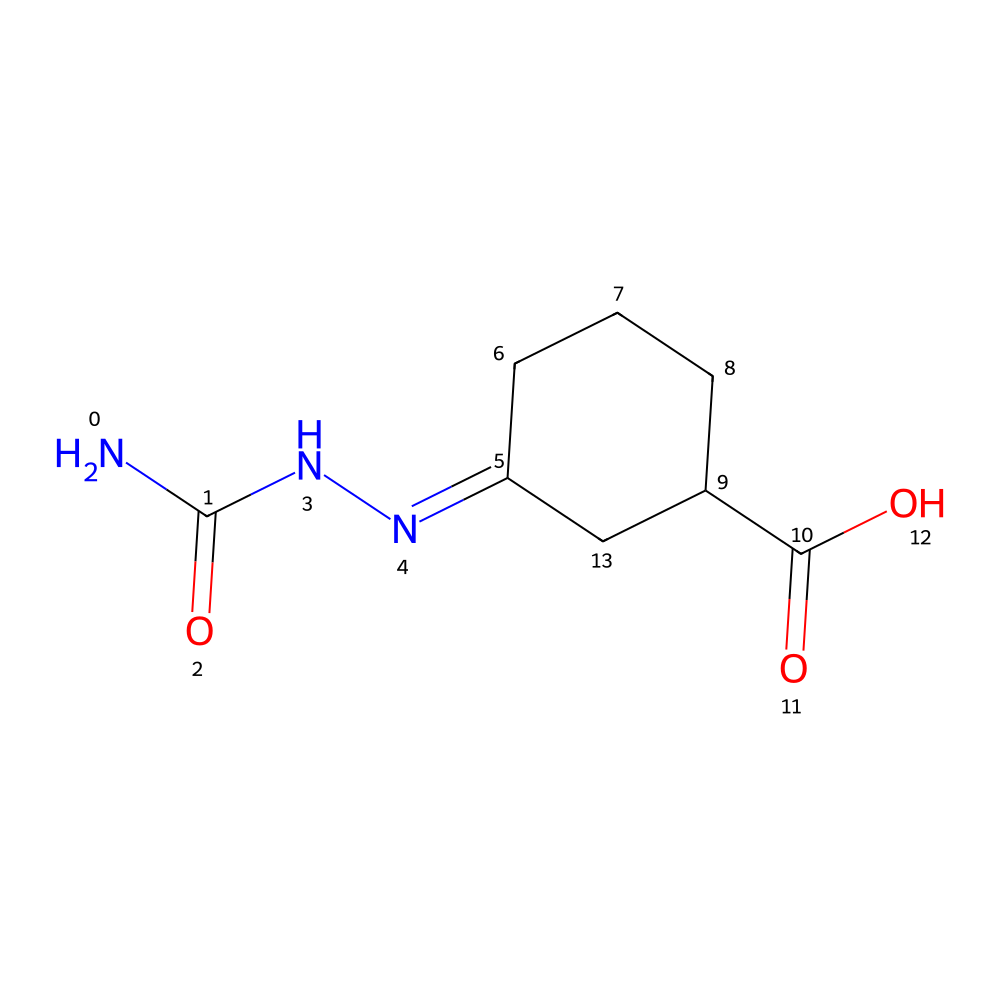

In [5]:
# Get atom ids

for atom in mol.GetAtoms():
    atom.SetProp('atomNote', f"{atom.GetIdx()}")

Draw.MolToImage(mol, size=(1000, 1000))

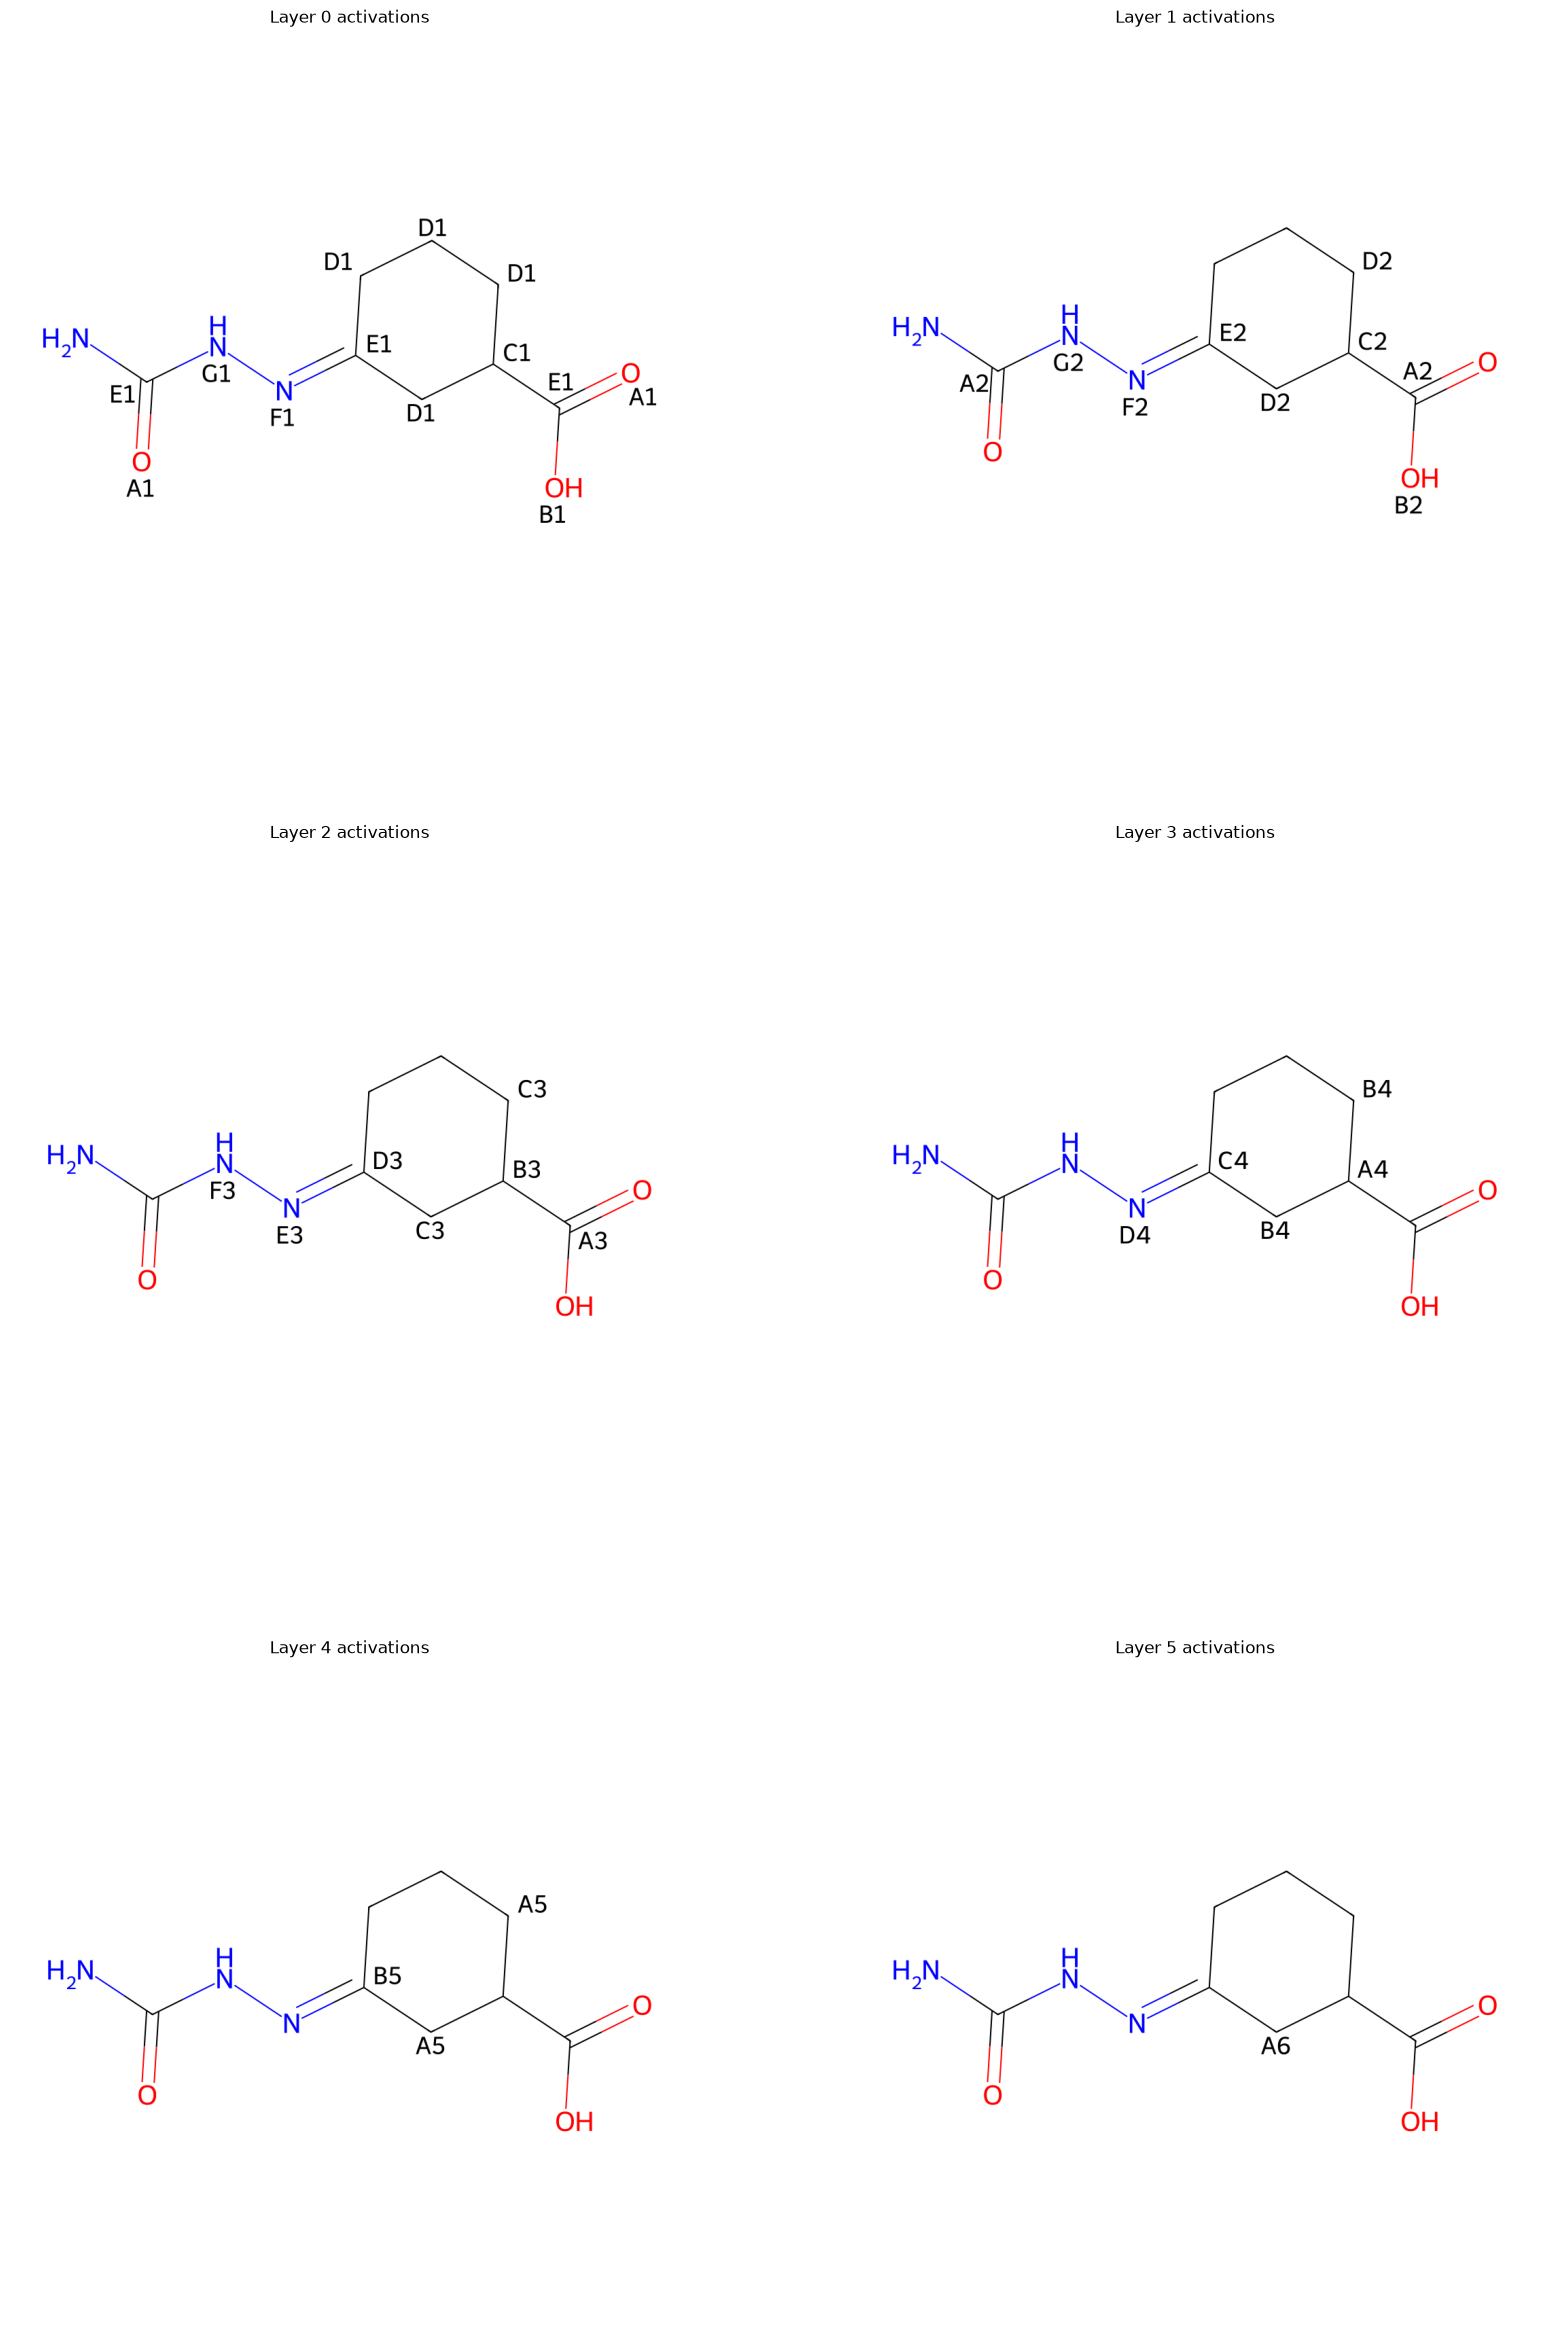

In [6]:
mol = Chem.MolFromSmiles(ultimately_suspicious_smiles)
x, edge_index, edge_features = mol_to_torch(mol)
_, activations = model(x, edge_features, edge_index, dump_activations=True)

imgs = visualize_all_activations(
    mol, activations
)

ncols = 2
nrows = len(imgs) // ncols + (len(imgs) % ncols > 0)

fig, axs = plt.subplots(nrows, ncols, figsize=(20, 10 * nrows))

for ax in axs.flatten():
    ax.axis('off')

for i, (img, ax) in enumerate(zip(imgs, axs.flatten())):
    ax.imshow(img)
    ax.set_title(f"Layer {i} activations")

plt.show()

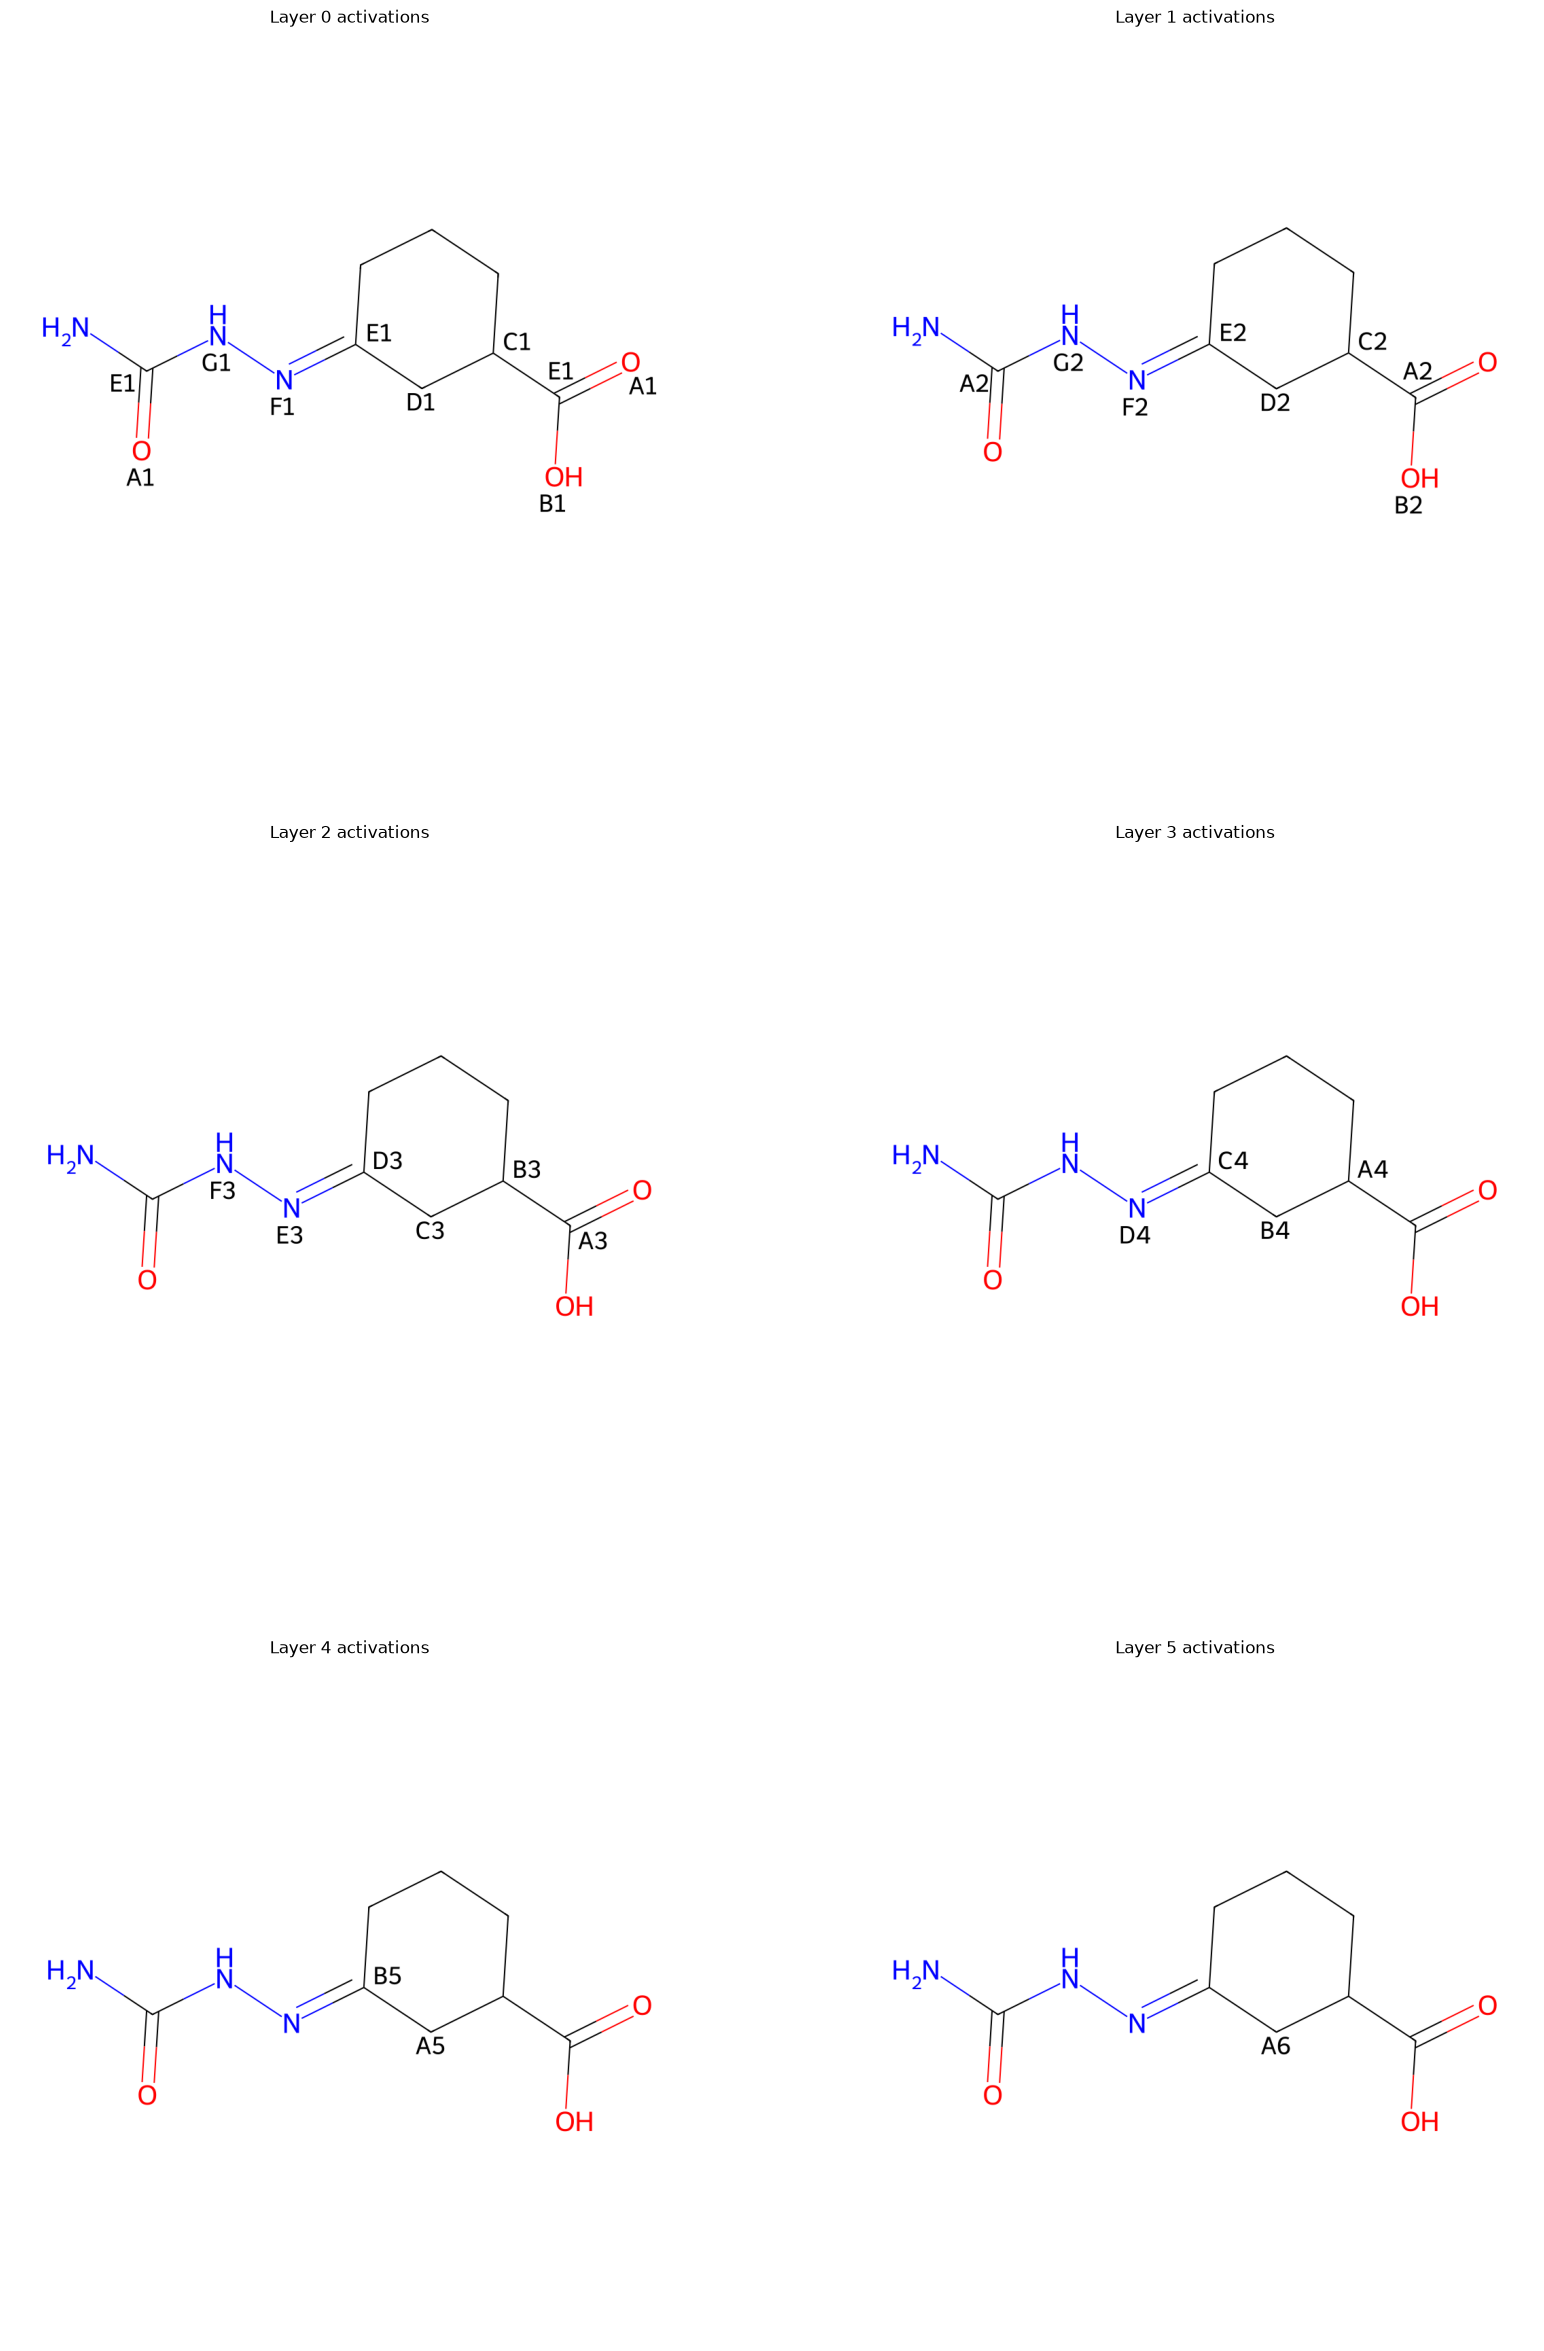

In [7]:
# And when atom 7 is zero'd out

mol = Chem.MolFromSmiles(ultimately_suspicious_smiles)
x, edge_index, edge_features = mol_to_torch(mol)

x_prim = x.clone()
x_prim[7] = torch.zeros_like(x_prim[7])

_, activations = model(x_prim, edge_features, edge_index, dump_activations=True)

imgs = visualize_all_activations(
    mol, activations
)

ncols = 2
nrows = len(imgs) // ncols + (len(imgs) % ncols > 0)

fig, axs = plt.subplots(nrows, ncols, figsize=(20, 10 * nrows))

for ax in axs.flatten():
    ax.axis('off')

for i, (img, ax) in enumerate(zip(imgs, axs.flatten())):
    ax.imshow(img)
    ax.set_title(f"Layer {i} activations")

plt.show()

In [8]:
model = MoleculeHDetector()

x, edge_index, edge_features = mol_to_torch(mol)
x_paths, e_paths, all_preds, all_activations = get_ig_gradient_paths(
    model=model,
    x=x,
    edge_index=edge_index,
    edge_features=edge_features,
    n_steps=5000
)

In [9]:
critical_points = []

threshold = 0.10
threshold_jump = 0.10

for i, pred in enumerate(all_preds):
    if pred > threshold:
        critical_points.append((threshold, i))
        threshold += threshold_jump

        print("Critical point found at step", i, "with prediction", pred)

Critical point found at step 4896 with prediction 0.10344469547271729
Critical point found at step 4909 with prediction 0.20174264907836914
Critical point found at step 4917 with prediction 0.3028082251548767
Critical point found at step 4923 with prediction 0.4096341133117676
Critical point found at step 4927 with prediction 0.5004935264587402
Critical point found at step 4931 with prediction 0.6109662652015686
Critical point found at step 4934 with prediction 0.7091347575187683
Critical point found at step 4937 with prediction 0.8226891160011292
Critical point found at step 4939 with prediction 0.9080607891082764
Critical point found at step 4941 with prediction 1.0


In [10]:
x_paths.shape

torch.Size([14, 110, 5000])

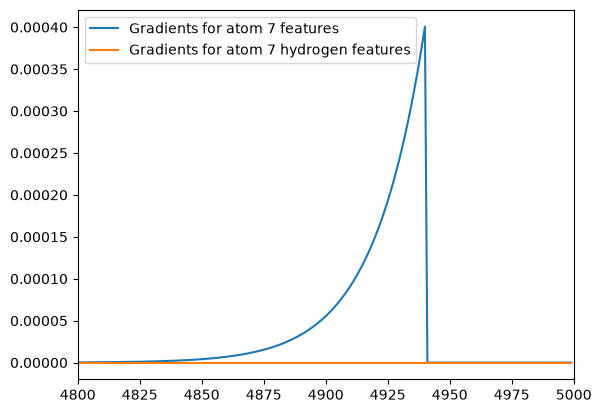

In [11]:
atom_7_path = x_paths[7]

atom_feats = atom_7_path[:100]
hydrogen_feats = atom_7_path[100:]

atom_feats = torch.sum(atom_feats, dim=0)
hydrogen_feats = torch.sum(hydrogen_feats, dim=0)

plt.plot(atom_feats.cpu().numpy(), label="Gradients for atom 7 features")
plt.plot(hydrogen_feats.cpu().numpy(), label="Gradients for atom 7 hydrogen features")
plt.legend()

plt.xlim(4800, 5000)

plt.show()

tikz_atom_feats = [(i / 5000, 5000 * feat.item()) for i, feat in enumerate(atom_feats.cpu().numpy())]
tikz_hydrogen_feats = [(i / 5000, 5000 * feat.item()) for i, feat in enumerate(hydrogen_feats.cpu().numpy())]

df_atom_feats = pd.DataFrame(tikz_atom_feats, columns=["Step", "Gradient"])
df_hydrogen_feats = pd.DataFrame(tikz_hydrogen_feats, columns=["Step", "Gradient"])

df_atom_feats.to_csv("notebook_artifacts/atom_7_feats_gradients.csv", index=False)
df_hydrogen_feats.to_csv("notebook_artifacts/atom_7_hydrogen_feats_gradients.csv", index=False)

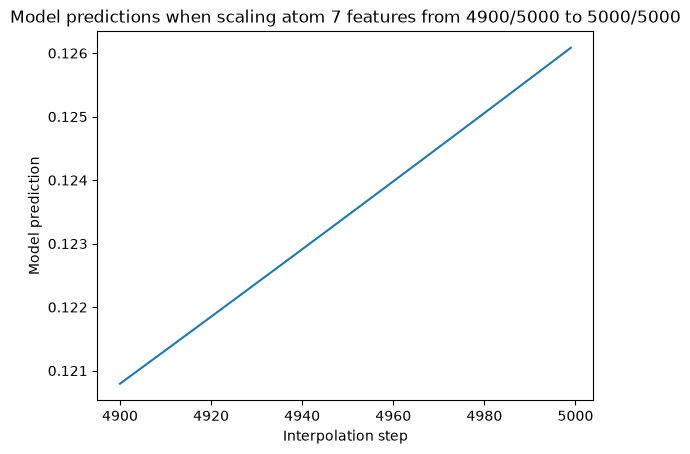

In [12]:
# Show what happens when x is scaled to 4900/5000 and we increase the features of atom 7

x_scaled = x.clone() * (4900 / 5000)
edge_features_scaled = edge_features.clone() * (4900 / 5000)
preds = []

for interpolation_step in range(4900, 5000):
    x_scaled[7] = x[7] * (interpolation_step / 5000)

    with torch.no_grad():
        pred = model(x_scaled, edge_features_scaled, edge_index)

    preds.append(pred.item())

plt.plot(range(4900, 5000), preds)
plt.title("Model predictions when scaling atom 7 features from 4900/5000 to 5000/5000")
plt.xlabel("Interpolation step")
plt.ylabel("Model prediction")
plt.show()

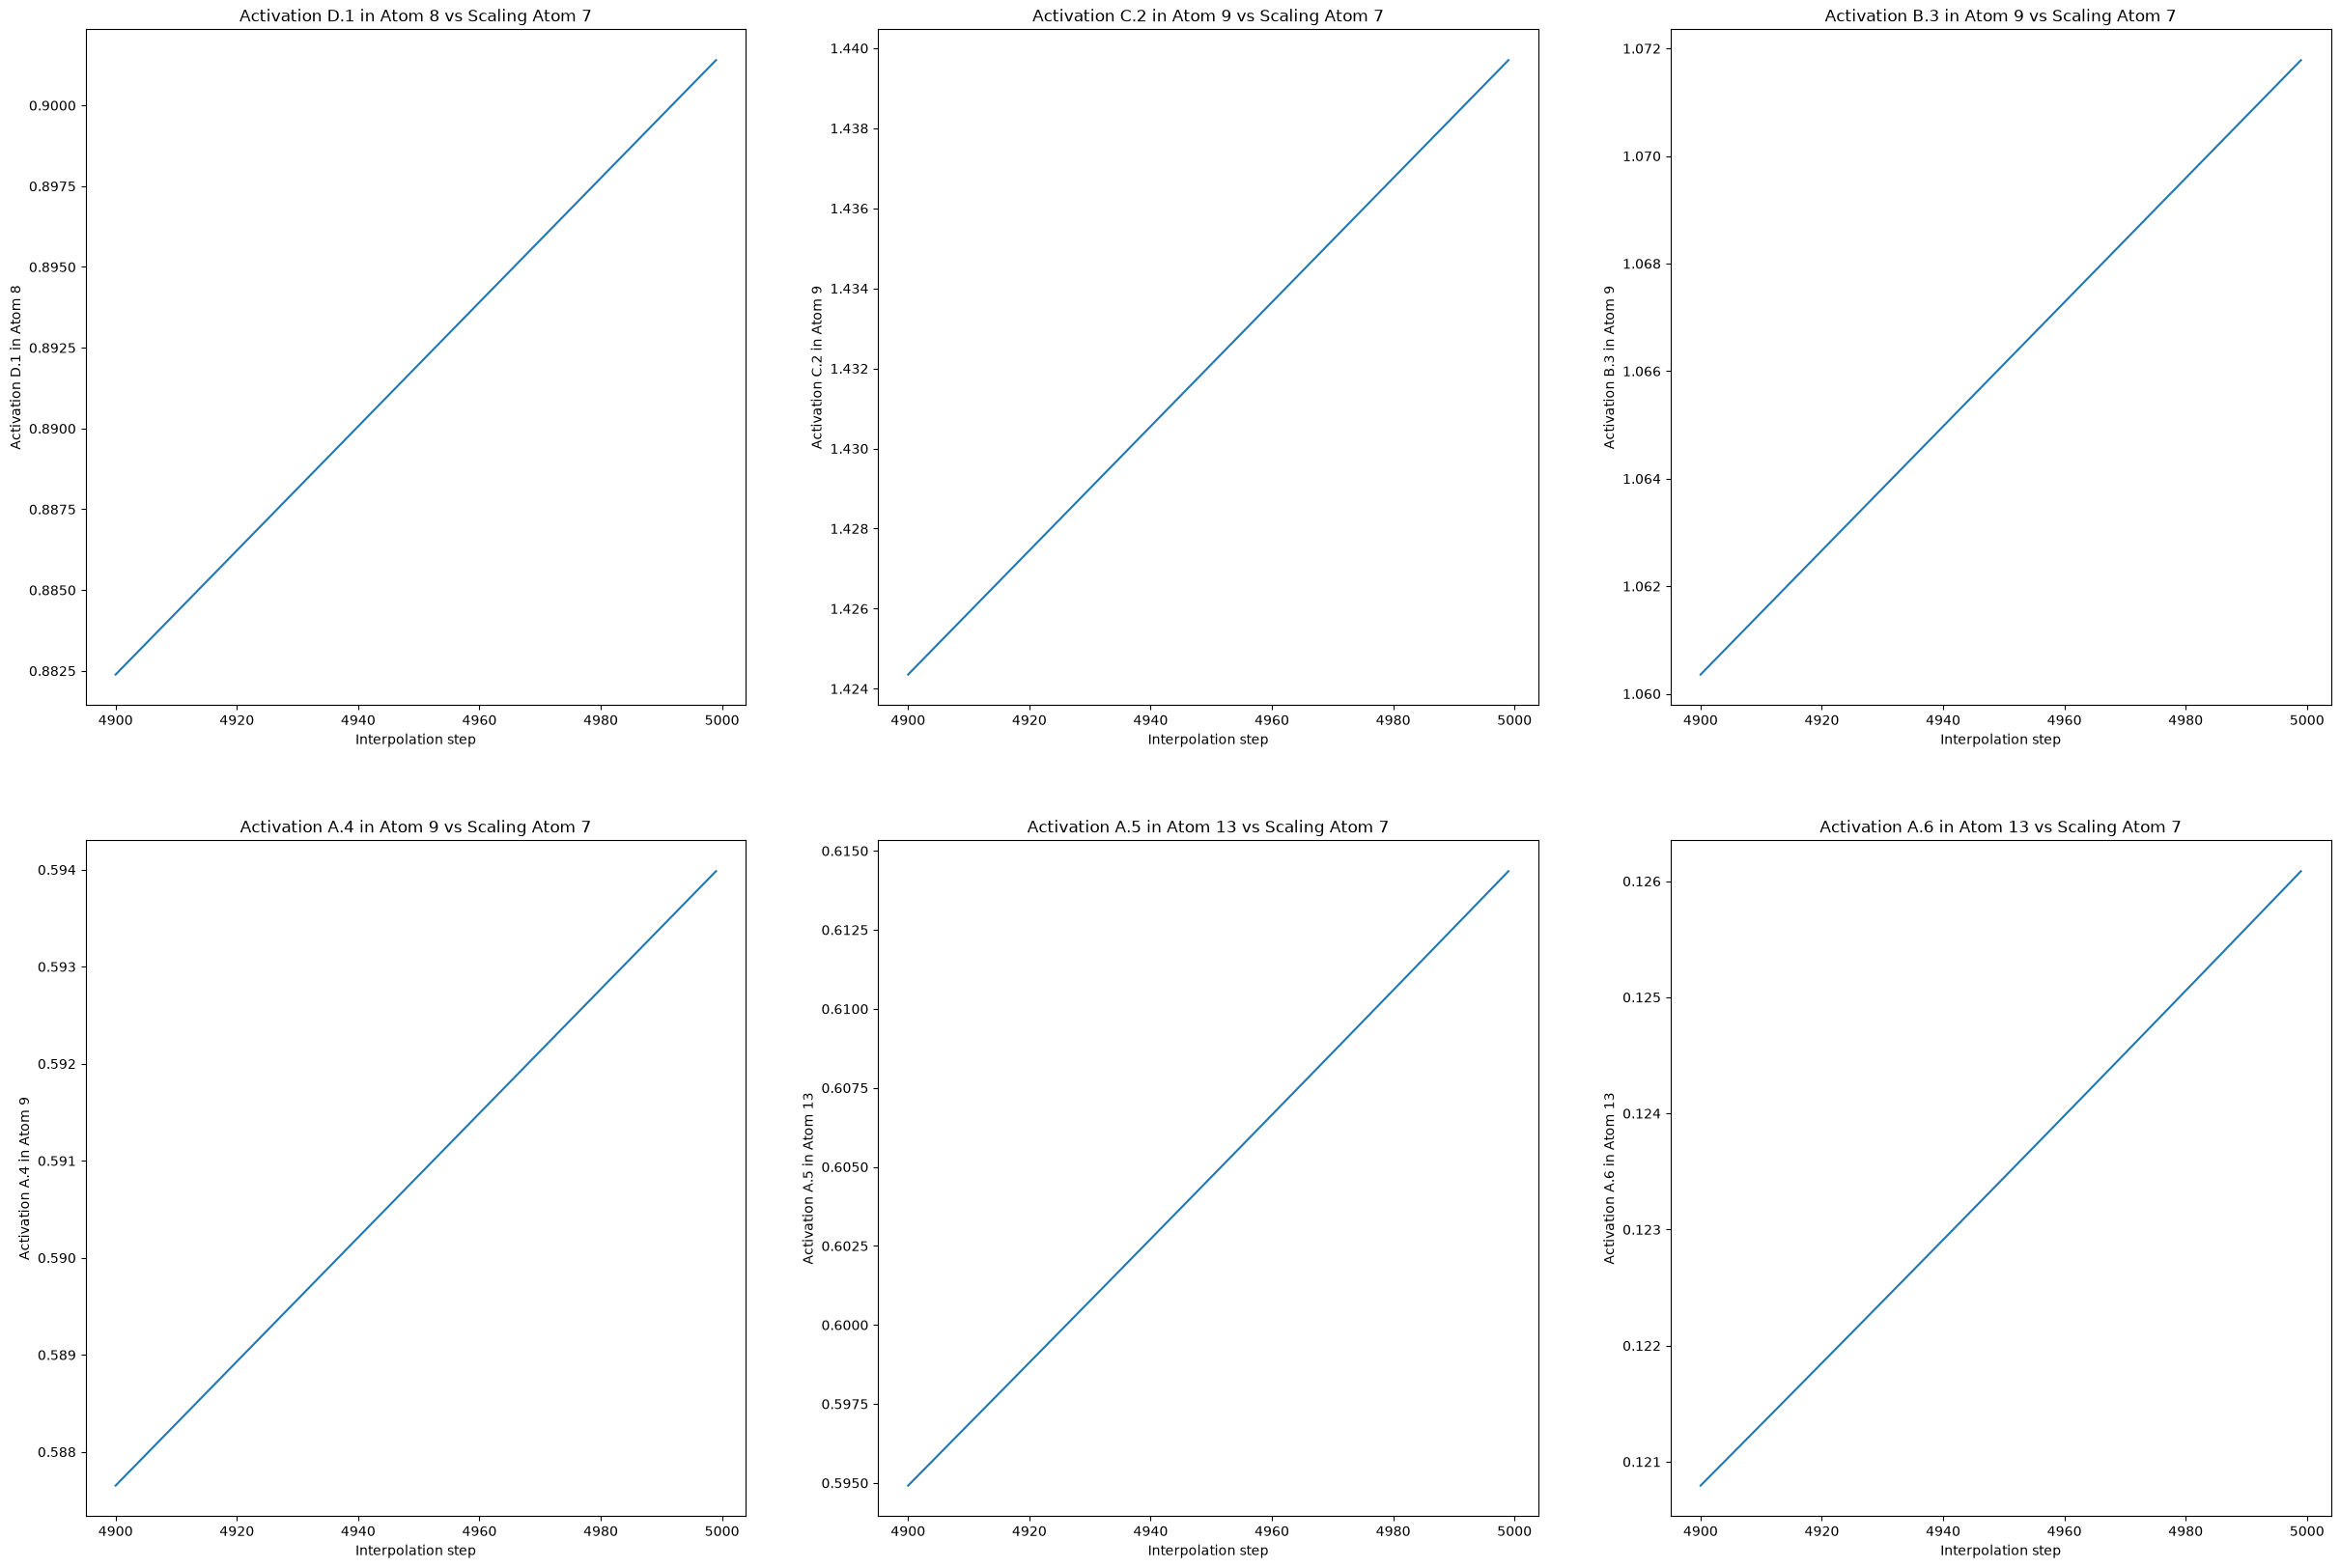

In [13]:
INVESTIGATION_OF_ATOM_IDX = 7

model = MoleculeHDetector()


def check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx, activation_name: str, ax):
    # For example C.5 -> (2, 4)
    activation_idx_letter, layer_idx = activation_name.split(".")

    # Activation idx letter is a letter from A to Z, where A=0, B=1, ..., Z=25
    activation_idx = ord(activation_idx_letter) - ord("A")
    layer_idx = int(layer_idx) - 1

    x_scaled = x.clone() * (4900 / 5000)
    edge_features_scaled = edge_features.clone() * (4900 / 5000)
    preds = []
    neighbour_activations = []

    for interpolation_step in range(4900, 5000):
        x_scaled[INVESTIGATION_OF_ATOM_IDX] = x[INVESTIGATION_OF_ATOM_IDX] * (interpolation_step / 5000)

        with torch.no_grad():
            pred, activations = model(x_scaled, edge_features_scaled, edge_index, dump_activations=True)

        layer_activations = activations[layer_idx]
        atom_activations = layer_activations[atom_idx]
        activation = atom_activations[activation_idx].item()

        neighbour_activations.append(activation)
        preds.append(pred.item())

    ax.plot(range(4900, 5000), neighbour_activations)
    ax.set_xlabel("Interpolation step")
    ax.set_ylabel(f"Activation {activation_name} in Atom {atom_idx}")
    ax.set_title(f"Activation {activation_name} in Atom {atom_idx} vs Scaling Atom {INVESTIGATION_OF_ATOM_IDX}")

    return ax, neighbour_activations, preds


fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(30, 20))

_, atom_8_activations, full_predictions = check_activation_against_atom_scaling(model, x, edge_index, edge_features,
                                                                                atom_idx=8, activation_name="D.1",
                                                                                ax=axs[0, 0])

d18 = atom_8_activations

_, c29, _ = check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx=9,
                                                  activation_name="C.2",
                                                  ax=axs[0, 1])

_, b39, _ = check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx=9,
                                                  activation_name="B.3",
                                                  ax=axs[0, 2])

_, a49, _ = check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx=9,
                                                  activation_name="A.4",
                                                  ax=axs[1, 0])

_, a513, _ = check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx=13,
                                                   activation_name="A.5",
                                                   ax=axs[1, 1])

_, a613, _ = check_activation_against_atom_scaling(model, x, edge_index, edge_features, atom_idx=13,
                                                   activation_name="A.6",
                                                   ax=axs[1, 2])

plt.show()


In [14]:
def activations_to_tikz(acts, path):
    acts = [((4900 + i) / 5000, act) for i, act in enumerate(acts)]
    df = pd.DataFrame(acts, columns=["Step", "Activation"])
    df.to_csv(path, index=False)


activations_to_tikz(
    d18, "notebook_artifacts/pattern_5_investigation/d18_activations_vs_scaling_atom_7.csv"
)

activations_to_tikz(
    c29, "notebook_artifacts/pattern_5_investigation/c29_activations_vs_scaling_atom_7.csv"
)

activations_to_tikz(
    b39, "notebook_artifacts/pattern_5_investigation/b39_activations_vs_scaling_atom_7.csv"
)

activations_to_tikz(
    a49, "notebook_artifacts/pattern_5_investigation/a49_activations_vs_scaling_atom_7.csv"
)

activations_to_tikz(
    a513, "notebook_artifacts/pattern_5_investigation/a513_activations_vs_scaling_atom_7.csv"
)

activations_to_tikz(
    a613, "notebook_artifacts/pattern_5_investigation/a613_activations_vs_scaling_atom_7.csv"
)


In [15]:
# To TikZ!

# Atom activations, tikzed
tikz_atom_8_activations = [((4900 + i) / 5000, act) for i, act in enumerate(atom_8_activations)]
tikz_full_predictions = [((4900 + i) / 5000, pred) for i, pred in enumerate(full_predictions)]

tikz_atom_8_activations_df = pd.DataFrame(tikz_atom_8_activations, columns=["Step", "Activation"])
tikz_full_predictions_df = pd.DataFrame(tikz_full_predictions, columns=["Step", "Prediction"])

tikz_atom_8_activations_df.to_csv("notebook_artifacts/atom_8_activations_vs_scaling_atom_7.csv", index=False)
tikz_full_predictions_df.to_csv("notebook_artifacts/full_predictions_vs_scaling_atom_7.csv", index=False)


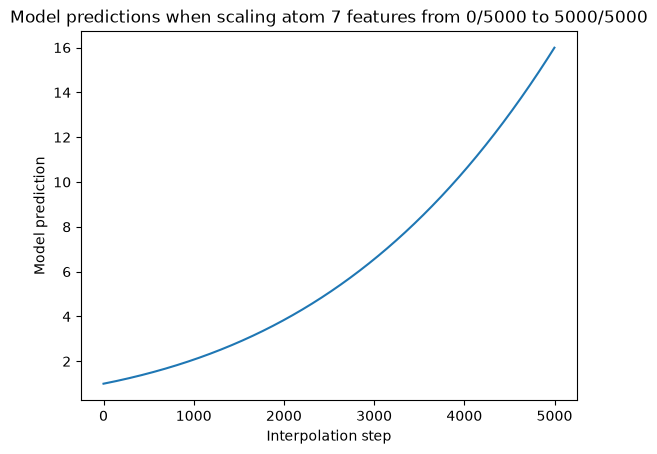

In [16]:
# And how scaling atom 7 affects the prediction when everyone else is in place
model = MoleculeHDetector()
model.readout = AllNonZeroMaxReadout()
x, edge_index, edge_features = mol_to_torch(mol)

preds = []

for interpolation_step in range(5000):
    x_scaled = x.clone()
    x_scaled[7] = x[7] * (interpolation_step / 5000)

    with torch.no_grad():
        pred = model(x_scaled, edge_features, edge_index)

    preds.append(pred.item())

plt.plot(range(5000), preds)
plt.title("Model predictions when scaling atom 7 features from 0/5000 to 5000/5000")
plt.xlabel("Interpolation step")
plt.ylabel("Model prediction")
plt.show()

tikz_pairs = [(i / 5000, pred) for i, pred in enumerate(preds)]

tikz_pairs_df = pd.DataFrame(tikz_pairs, columns=["Step", "Prediction"])
tikz_pairs_df.to_csv("notebook_artifacts/predictions_vs_scaling_atom_7_r1.csv", index=False)

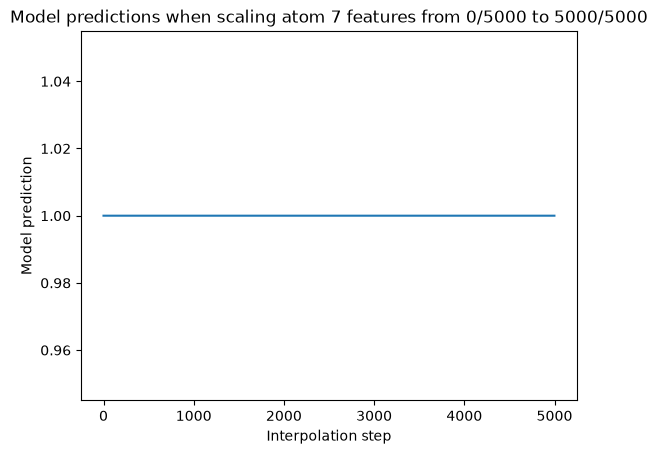

In [17]:
# And how scaling atom 7 affects the prediction when everyone else is in place
model = MoleculeHDetector()  # R2
x, edge_index, edge_features = mol_to_torch(mol)

preds = []

for interpolation_step in range(5000):
    x_scaled = x.clone()
    x_scaled[7] = x[7] * (interpolation_step / 5000)

    with torch.no_grad():
        pred = model(x_scaled, edge_features, edge_index)

    preds.append(pred.item())

plt.plot(range(5000), preds)
plt.title("Model predictions when scaling atom 7 features from 0/5000 to 5000/5000")
plt.xlabel("Interpolation step")
plt.ylabel("Model prediction")
plt.show()

tikz_pairs = [(i / 5000, pred) for i, pred in enumerate(preds)]

tikz_pairs_df = pd.DataFrame(tikz_pairs, columns=["Step", "Prediction"])
tikz_pairs_df.to_csv("notebook_artifacts/predictions_vs_scaling_atom_7_r2.csv", index=False)

In [18]:
import string

x, edge_index, edge_features = mol_to_torch(mol)
x_prim = x.clone()
x_prim[7] = torch.zeros_like(x_prim[7])

_, all_activations = model(x, edge_features, edge_index, dump_activations=True)
_, all_activations_prim = model(x_prim, edge_features, edge_index, dump_activations=True)

for layer_idx, (activations, activations_prim) in enumerate(zip(all_activations, all_activations_prim)):
    for atom_idx, (atom_activations, atom_activations_prim) in enumerate(zip(activations, activations_prim)):
        for activation_idx, (activation, activation_prim) in enumerate(zip(atom_activations, atom_activations_prim)):
            if activation.item() != activation_prim.item():
                print(f"Layer {layer_idx + 1}, Atom {atom_idx}, Activation {string.ascii_uppercase[activation_idx]}: "
                      f"{activation_prim.item()} -> {activation.item()}")

Layer 1, Atom 6, Activation D: 0.0 -> 1.0
Layer 1, Atom 7, Activation D: 0.0 -> 1.0
Layer 1, Atom 8, Activation D: 0.0 -> 1.0
Layer 2, Atom 8, Activation D: 0.0 -> 1.0
Layer 2, Atom 9, Activation C: 1.0 -> 2.0
Layer 3, Atom 8, Activation C: 0.0 -> 2.0
Layer 3, Atom 9, Activation B: 1.0 -> 2.0
Layer 3, Atom 13, Activation C: 1.0 -> 2.0
Layer 4, Atom 5, Activation C: 1.0 -> 2.0
Layer 4, Atom 8, Activation B: 0.0 -> 4.0
Layer 4, Atom 9, Activation A: 1.0 -> 2.0
Layer 4, Atom 13, Activation B: 1.0 -> 4.0
Layer 5, Atom 5, Activation B: 1.0 -> 2.0
Layer 5, Atom 8, Activation A: 0.0 -> 8.0
Layer 5, Atom 13, Activation A: 1.0 -> 8.0
Layer 6, Atom 13, Activation A: 1.0 -> 16.0
